# GCAP3226 Week 3 — Graded in-class exercise (5%)

**Individual** · submit via **your GitHub fork** (end of notebook). Keep answers short.

### What is marked
| Task | Focus |
|------|--------|
| **1** | Stacked bar: one factor **other than** `government_consideration` vs `support_info` + your trend description |
| **2** | Multiple linear regression that builds on the demo, adding `policy_helpfulness` and `waste_severity` + short coefficient interpretation |
| **3** | **Your own** IPO prompt → simple linear regression: `support_info` vs `fairness` |
| **Submit** | Save → Source Control → **Commit & Push** → **commit message** → Commit → Moodle **GitHub URL** |

Use **association** language only. This is a **non-probability** sample — do not claim causation or “all of Hong Kong”.


## How to use AI here (Codespaces)

In the demo you practiced **Input → Process → Output** prompts (**Write Python code** in Process).

**Tasks 1–2:** the prompt is already in the code cell as comments.

**Task 3:** you **write the prompt yourself** in the comments, then use Inline Chat.

Workflow:
1. Click inside the code cell.  
2. Edit / write the comment prompt.  
3. Press **`Cmd+I`** (Mac) or **`Ctrl+I`** (Windows/Linux).  
4. Ask e.g. *Implement the prompt in the comments above* → **Keep**.  
5. Fix anything that breaks; write interpretations **in your own words**.


## Setup (run once)

Load `week3.csv`. Glance at the column names so you know what you can use.


In [27]:
# Setup — run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression

DATA_FILE = "week3.csv"


def load_week3_data():
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            print("Using data file:", p.resolve())
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Work in your Week 3 fork / Codespace."
    )


df = load_week3_data()
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()


Using data file: /workspaces/GCAP3226_week3/week3.csv
shape: (97, 12)
columns: ['ID', 'support_info', 'support_after_info', 'government_consideration', 'fairness', 'policy_helpfulness', 'waste_severity', 'recycling_effort', 'age_group', 'monthly_income', 'education', 'education_label']


,ID,support_info,support_after_info,government_consideration,fairness,policy_helpfulness,waste_severity,recycling_effort,age_group,monthly_income,education,education_label
0,1,1,1,1,1,1,3,1,29.5,22500.5,4,Master or above
1,2,5,5,5,5,4,2,2,39.5,7500.0,4,Master or above
2,3,3,5,4,5,2,3,1,29.5,22500.5,4,Master or above
3,4,1,2,1,2,2,3,2,29.5,60000.5,4,Master or above
4,5,1,3,3,4,1,3,2,49.5,22500.5,2,Secondary


## Task 1 — Stacked bar (not the demo pair)

In the demo, the stacked bar used **`government_consideration`** (groups) × **`support_info`** (stack, row %).

**Your job:** choose a **different** grouping variable from `week3.csv` and plot a **row-% stacked bar** of `support_info` within each group.

### Suggested grouping variables (pick one)
| Variable | Notes |
|----------|--------|
| `fairness` | 1–5 |
| `policy_helpfulness` | 1–4 |
| `waste_severity` | 1–4 |
| `recycling_effort` | 1–4 |
| `education` | 1–4 |

Do **not** use `government_consideration` as the grouping variable.

In the **next code cell**, replace `<YOUR_GROUP_VAR>` in the comment prompt with your choice, then use Inline Chat (see **How to use AI** above).


In [5]:
# Task 1 — Stacked bar
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to make a row-percentage stacked bar chart of
#   support_info within each level of <Fairness>.
#   Drop rows with missing values for these columns. Show n for each group if you can.
#   Add comments to key Python code.
# Output: A stacked bar chart with title, axis labels, and legend.
# --- End prompt ---
# EDIT: replace <Fairness> above with one name from the allowlist
#       (NOT government_consideration). Then use Inline Chat on this cell.
#
# --- generated / your code below ---


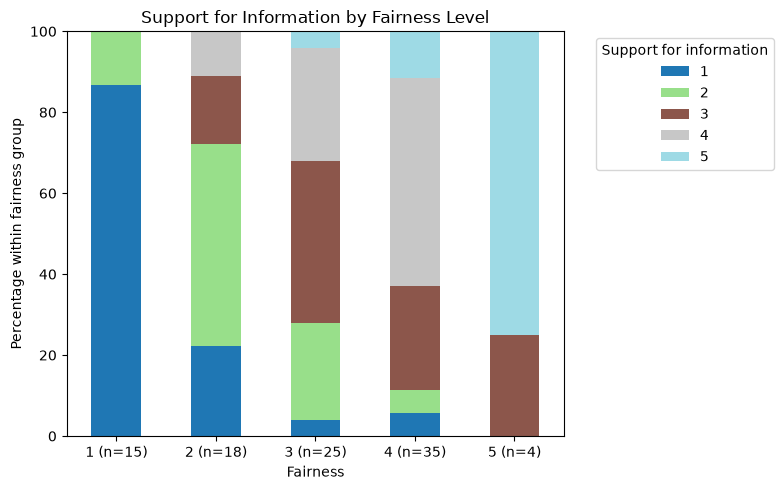

In [6]:
# Use fairness as the grouping variable and remove incomplete rows.
group_var = "fairness"
plot_df = df[[group_var, "support_info"]].dropna()

# Count support_info responses within each fairness level.
counts = pd.crosstab(plot_df[group_var], plot_df["support_info"]).sort_index()

# Convert counts to row percentages.
row_percent = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot the row-percentage stacked bar chart.
ax = row_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    colormap="tab20"
)

# Add sample sizes to the x-axis labels.
sample_sizes = counts.sum(axis=1)
ax.set_xticklabels(
    [f"{level} (n={int(sample_sizes.loc[level])})" for level in counts.index],
    rotation=0
)

ax.set_title("Support for Information by Fairness Level")
ax.set_xlabel("Fairness")
ax.set_ylabel("Percentage within fairness group")
ax.legend(title="Support for information", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Task 1 — Describe the trend (your words)

In 2–4 sentences: what pattern do you see in **this sample**? Use association language. Mention any thin groups (small *n*) if relevant.

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [7]:
# Task 1 — write BETWEEN the triple quotes, then RUN this cell
task1_trend = """
# What trend do you see?

"""
print(task1_trend)



# What trend do you see?




In [ ]:
task1_trend = """
Higher fairness ratings are associated with higher support for information in this sample. 
At fairness level 1, most respondents selected low support, while levels 4 and 5 had more high-support responses. 
The fairness level 5 group is small (n=4), so its pattern should be interpreted cautiously.
"""
print(task1_trend)

## Task 2 — Multiple linear regression (+ policy & severity)

In the demo you fitted multiple linear regression with `government_consideration` and `fairness` (and a fuller model with demographics).

**Your job:** fit a multiple linear regression for this sample:

**Response:** `support_info`  

**Exploratory variables (at least these four):**
- `government_consideration`
- `fairness`
- `policy_helpfulness`
- `waste_severity`

Use complete cases for these columns. Print **each coefficient**, **R²**, and **n**.  

In the **next code cell**, use the comment prompt with Inline Chat (see **How to use AI** above).


In [9]:
# Task 2 — Multiple linear regression
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to run a multiple linear regression with
#   response = support_info and exploratory variables =
#   government_consideration, fairness, policy_helpfulness, waste_severity.
#   Use rows with no missing values on these columns.
#   Print coefficients, R-squared, and n.
#   Add comments to key Python code.
# Output: A clear coefficient table (or printed list), R², and sample size n.
# --- End prompt ---
#
# --- generated / your code below ---


In [ ]:
# If the setup cell has not been run yet, load the dataset and imports.
if "df" not in globals():
    import pandas as pd
    from pathlib import Path
    from sklearn.linear_model import LinearRegression

    DATA_FILE = "week3.csv"
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            df = pd.read_csv(p)
            break
    else:
        raise FileNotFoundError(
            f"Could not find {DATA_FILE}. Work in your Week 3 fork / Codespace."
        )

# Select the response and required exploratory variables.
response = "support_info"
predictors = [
    "government_consideration",
    "fairness",
    "policy_helpfulness",
    "waste_severity",
]

# Keep only complete cases for the regression variables.
model_df = df[[response] + predictors].dropna()

X = model_df[predictors]
y = model_df[response]

# Fit the multiple linear regression model.
model = LinearRegression()
model.fit(X, y)

# Print the intercept and each coefficient.
print("Intercept:", model.intercept_)
for variable, coefficient in zip(predictors, model.coef_):
    print(f"{variable}: {coefficient}")

print("R-squared:", model.score(X, y))
print("n:", len(model_df))


Intercept: -0.27679212046097
government_consideration: 0.4832645758847302
fairness: 0.37863881949307115
policy_helpfulness: 0.1924143110526489
waste_severity: 0.1179674743218849
R-squared: 0.6387240598479557
n: 97


### Task 2 — Report & briefly interpret

1. Paste or list the **coefficients** (and R², n) from your output.  
2. In a few sentences, interpret **two** coefficients that interest you (association; holding the other variables fixed).  
3. One caution (sample / overclaim).

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [11]:
# Task 2 — write BETWEEN the triple quotes, then RUN this cell
task2_writeup = """
# Coefficients / R² / n:

# Interpretation (2 coefficients you care about):

# One caution: (sample / causation)

"""
print(task2_writeup)



# Coefficients / R² / n:

# Interpretation (2 coefficients you care about):

# One caution: (sample / causation)




In [12]:
# Task 2 — completed report
coefficient_lines = [
    f"{name}: {value:.3f}"
    for name, value in zip(predictors, model.coef_)
]

task2_writeup = f"""
# Coefficients / R² / n:
Intercept: {model.intercept_:.3f}
{chr(10).join(coefficient_lines)}
R²: {model.score(X, y):.3f}
n: {len(model_df)}

# Interpretation (2 coefficients you care about):
Holding the other variables fixed, a one-unit increase in fairness is
associated with a {model.coef_[1]:.3f}-unit change in predicted support_info.

Holding the other variables fixed, a one-unit increase in government_consideration
is associated with a {model.coef_[0]:.3f}-unit change in predicted support_info.

# One caution: This is a non-probability sample, so these associations should not
be generalized to all of Hong Kong or interpreted as causal effects.
"""

print(task2_writeup)


# Coefficients / R² / n:
Intercept: -0.277
government_consideration: 0.483
fairness: 0.379
policy_helpfulness: 0.192
waste_severity: 0.118
R²: 0.639
n: 97

# Interpretation (2 coefficients you care about):
Holding the other variables fixed, a one-unit increase in fairness is
associated with a 0.379-unit change in predicted support_info.

Holding the other variables fixed, a one-unit increase in government_consideration
is associated with a 0.483-unit change in predicted support_info.

# One caution: This is a non-probability sample, so these associations should not
be generalized to all of Hong Kong or interpreted as causal effects.



## Task 3 — Write your own prompt (simple linear regression)

**Goal:** `support_info` (response) vs `fairness` (one exploratory variable) — a **simple** linear regression on this sample.

Unlike Tasks 1–2, **do not** copy a ready-made Process. In the **next code cell**, write the full **Input / Process / Output** in the comments (**Process** must include **Write Python code**), then use Inline Chat (see **How to use AI** above).

Keep the model to **these two variables only** (not the Task 2 multiple linear regression). You should get coefficients, R², and n.

### Task 3 — Short note

In 1–2 sentences: what does the **fairness** slope mean in this simple linear regression? How does it compare (roughly) with the fairness coefficient in your **Task 2** multiple linear regression?

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell.


## Task 3 — Write your own prompt (simple linear regression)

**Goal:** `support_info` (response) vs `fairness` (one exploratory variable) — a **simple** linear regression on this sample.

Unlike Tasks 1–2, **do not** copy a ready-made Process. In the **next code cell**, write the full **Input / Process / Output** in the comments (**Process** must include **Write Python code**), then use Inline Chat (see **How to use AI** above).

Keep the model to **these two variables only** (not the Task 2 multiple linear regression). You should get coefficients, R², and n.


In [18]:
#--- Input → Process → Output ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to run a simple linear regression with response = support_info and
#         one exploratory variable = fairness. Use complete cases for these
#   two variables and fit a simple linear regression on this sample.
#         Use only support_info and fairness in the model. Print the intercept,
#     fairness coefficient, R-squared, and n. Add comments to key code.
# Output: Printed a simple linear regression result with intercept, slope, R-squared and n, plus a scatter plot
# --- End prompt ---

# Keep only rows with non-missing values for the response and predictor.

Intercept: 0.49503523382447145
Fairness coefficient: 0.7936418962203715
R-squared: 0.5219498894120836
n: 97


/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


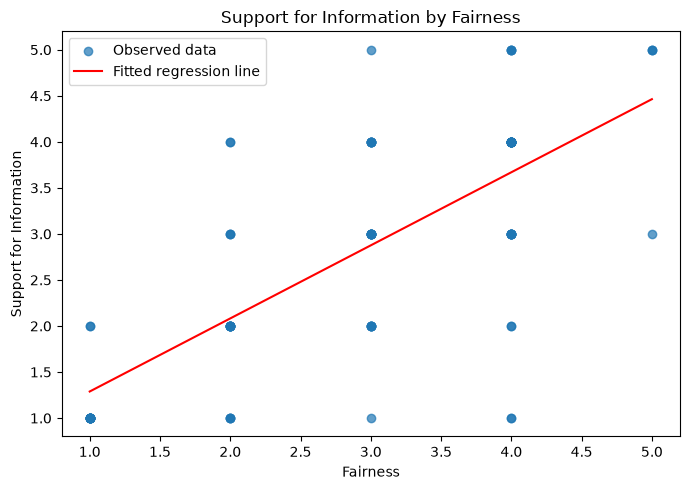

In [28]:
# If the setup cell has not run yet, load the dataset and imports.
if "df" not in globals():
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path
    from sklearn.linear_model import LinearRegression

    DATA_FILE = "week3.csv"
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            df = pd.read_csv(p)
            break
    else:
        raise FileNotFoundError(
            f"Could not find {DATA_FILE}. Work in your Week 3 fork / Codespace."
        )

# Keep only complete cases for the two model variables.
simple_df = df[["support_info", "fairness"]].dropna()
X_simple = simple_df[["fairness"]]
y_simple = simple_df["support_info"]

# Fit the simple linear regression model.
simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)

# Print the regression results.
print("Intercept:", simple_model.intercept_)
print("Fairness coefficient:", simple_model.coef_[0])
print("R-squared:", simple_model.score(X_simple, y_simple))
print("n:", len(simple_df))

# Plot the observations and fitted regression line.
plt.figure(figsize=(7, 5))
plt.scatter(X_simple["fairness"], y_simple, alpha=0.7, label="Observed data")

fairness_range = np.linspace(
    X_simple["fairness"].min(),
    X_simple["fairness"].max(),
    100
).reshape(-1, 1)

plt.plot(
    fairness_range,
    simple_model.predict(fairness_range),
    color="red",
    label="Fitted regression line"
)

plt.title("Support for Information by Fairness")
plt.xlabel("Fairness")
plt.ylabel("Support for Information")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# If the Task 2 model is not available, build it so the comparison still works.
if "model" not in globals():
    if "df" not in globals():
        import pandas as pd
        from pathlib import Path
        from sklearn.linear_model import LinearRegression

        DATA_FILE = "week3.csv"
        for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
            if p.is_file():
                df = pd.read_csv(p)
                break
        else:
            raise FileNotFoundError(
                f"Could not find {DATA_FILE}. Work in your Week 3 fork / Codespace."
            )

    response = "support_info"
    predictors = [
        "government_consideration",
        "fairness",
        "policy_helpfulness",
        "waste_severity",
    ]
    model_df = df[[response] + predictors].dropna()
    X = model_df[predictors]
    y = model_df[response]
    model = LinearRegression()
    model.fit(X, y)

# Build the short note comparing the simple and multiple regression fairness slopes.
task3_note = f"""
A one-unit increase in fairness is associated with a
{simple_model.coef_[0]:.3f}-unit change in predicted support_info
in the simple regression. Compared with the Task 2 fairness coefficient
({model.coef_[1]:.3f}), the simple-regression coefficient is
{"larger" if abs(simple_model.coef_[0]) > abs(model.coef_[1]) else "smaller"} in absolute size.
"""
print(task3_note)



A one-unit increase in fairness is associated with a
0.794-unit change in predicted support_info
in the simple regression. Compared with the Task 2 fairness coefficient
(0.379), the simple-regression coefficient is
larger in absolute size.



In [31]:
# Task 3 — write BETWEEN the triple quotes, then RUN this cell
task3_note = """
# Fairness slope (simple linear regression) and vs Task 2:

"""
print(task3_note)



# Fairness slope (simple linear regression) and vs Task 2:




In [32]:
# Compare the fairness slopes from the simple and multiple regressions.
simple_slope = simple_model.coef_[0]
multiple_slope = model.coef_[1]

task3_note = f"""
Fairness slope (simple linear regression) and vs Task 2:

A one-unit increase in fairness is associated with a {simple_slope:.3f}-unit
increase in predicted support_info in the simple regression. The Task 2
fairness coefficient is {multiple_slope:.3f}; therefore, the simple slope is
{"larger" if abs(simple_slope) > abs(multiple_slope) else "smaller"} in absolute size.
"""
print(task3_note)


Fairness slope (simple linear regression) and vs Task 2:

A one-unit increase in fairness is associated with a 0.794-unit
increase in predicted support_info in the simple regression. The Task 2
fairness coefficient is 0.379; therefore, the simple slope is
larger in absolute size.



## How to submit

Submit the **GitHub URL** of this notebook in **your fork** (not an `.ipynb` upload).

1. **Save** the notebook.  
2. Open **Source Control** (left sidebar, branch icon).  
3. Click **Commit & Push**.  
4. Type a **commit message** → click **Commit**.  
5. On github.com, open the file in **your fork** → copy the browser URL.  
6. Paste that URL on **Moodle**.

**If push fails:** ask a TA — keep working toward a push to your fork.

### Checklist
- [ ] Task 1: stacked bar (not `government_consideration` groups) + trend description  
- [ ] Task 2: multiple linear regression with the four required variables + coefficient write-up  
- [ ] Task 3: **your own** IPO prompt + simple linear regression (`support_info` vs `fairness`)  
- [ ] Saved → Commit & Push → commit message → Commit  
- [ ] Moodle: GitHub link submitted  
